# Three Insurance Strategies Under Market Cycles

## Comparing Static, Size-Adaptive, and Fully Adaptive Approaches

This notebook compares three insurance purchasing strategies for a manufacturingcompany over a 25-year horizon under stochastic market cycles:

1. **Static** — Insurance optimized once for normal-market conditions at the initial company size. The retention and limit are never updated.
2. **Size-Adaptive** — Retention and limits are re-optimized each year for the current company size, always assuming a normal market (loss ratio = 0.70).
3. **Fully Adaptive** — Re-optimized each year for *both* current company size and the prevailing market cycle (Soft / Normal / Hard).Market cycles follow a 3-state Markov chain calibrated to underwriting-cycleliterature (Hamilton, 1989; Cummins & Outreville, 1987).

All three companiesface identical loss realizations via **Common Random Numbers (CRN)**, isolatingthe pure strategy effect from sampling noise.

**Key insight from ergodic economics**: the *time-average* growth rate — not theensemble average — determines long-run wealth. Adapting to market conditionscompounds small annual advantages into large terminal-wealth differences.-

**Audience**: Actuaries, CFOs, Risk Managers

In [1]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/optimization'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm as sp_norm, lognorm as sp_lognorm
from scipy.interpolate import interp1d
from concurrent.futures import ProcessPoolExecutor
import warnings, logging, time, multiprocessing, os

warnings.filterwarnings("ignore")
logging.getLogger("ergodic_insurance").setLevel(logging.ERROR)

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE, WSJFormatter,
)
from ergodic_insurance.config import ManufacturerConfig
from ergodic_insurance.manufacturer import WidgetManufacturer
from ergodic_insurance.insurance_program import (
    EnhancedInsuranceLayer, InsuranceProgram,
)
from ergodic_insurance.loss_distributions import (
    ManufacturingLossGenerator, LognormalLoss, ParetoLoss,
)
from ergodic_insurance.insurance_pricing import LayerPricer

SEED = 20260223
np.random.seed(SEED)
N_CORES = max(1, multiprocessing.cpu_count() - 1)
print(f"Using {N_CORES} of {multiprocessing.cpu_count()} cores")

Using 15 of 16 cores


## Part I — Company Configuration

Baseline manufacturing company. All three strategies start from the same initial conditions; differences emerge only from insurance-purchasing decisions.

In [3]:
# --- Economic Parameters ---
ATR = 2.0                 # Asset turnover ratio
OPERATING_MARGIN = 0.15   # 15% EBIT margin before insurable losses
REV_VOL = 0.10            # Revenue volatility (annualized; kept low so insurable-loss risk dominates)
INITIAL_ASSETS = 10_000_000
TAX_RATE = 0.25
RETENTION_RATIO = 0.70    # 70% of earnings retained for growth

mfg_config = ManufacturerConfig(
    initial_assets=INITIAL_ASSETS,
    asset_turnover_ratio=ATR,
    base_operating_margin=OPERATING_MARGIN,
    tax_rate=TAX_RATE,
    retention_ratio=RETENTION_RATIO,
)

revenue = INITIAL_ASSETS * ATR
ebit = revenue * OPERATING_MARGIN
print("=" * 60)
print("MANUFACTURING COMPANY PROFILE")
print("=" * 60)
print(f"Total Assets:          ${INITIAL_ASSETS:>14,.0f}")
print(f"Annual Revenue:        ${revenue:>14,.0f}")
print(f"Operating Income:      ${ebit:>14,.0f}")
print(f"Operating Margin:      {OPERATING_MARGIN:>14.1%}")
print(f"Asset Turnover:        {ATR:>14.1f}x")
print(f"Revenue Volatility:    {REV_VOL:>14.2f}")
print(f"Tax Rate:              {TAX_RATE:>13.1%}")
print(f"Retention Ratio:       {RETENTION_RATIO:>13.1%}")
print("=" * 60)

MANUFACTURING COMPANY PROFILE
Total Assets:          $    10,000,000
Annual Revenue:        $    20,000,000
Operating Income:      $     3,000,000
Operating Margin:               15.0%
Asset Turnover:                   2.0x
Revenue Volatility:              0.10
Tax Rate:                      25.0%
Retention Ratio:               70.0%


## Part II — Loss Model & Insurance Pricing

Three-component compound-Poisson loss model (attritional, large, catastrophic) with sub-linear frequency scaling in revenue. Insurance towers are priced analytically via Limited Expected Values (LEVs) so that rate-on-line decreases naturally as the retention rises.

In [4]:
REFERENCE_REVENUE = ATR * INITIAL_ASSETS
FREQ_SCALING_EXPONENT = 0.75

# --- Loss Model Parameters ---
ATTR_BASE_FREQ = 15;       ATTR_SEV_MEAN = 10_000;      ATTR_SEV_CV = 5
LG_BASE_FREQ   = 2.0;      LG_SEV_MEAN   = 200_000;     LG_SEV_CV   = 3
CAT_BASE_FREQ  = 0.15;     CAT_SEV_ALPHA = 1.5;         CAT_SEV_XM  = 2_000_000

LOSS_PARAMS = dict(
    attritional_params=dict(base_frequency=ATTR_BASE_FREQ,
                            severity_mean=ATTR_SEV_MEAN, severity_cv=ATTR_SEV_CV,
                            revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                            reference_revenue=REFERENCE_REVENUE),
    large_params=dict(base_frequency=LG_BASE_FREQ,
                      severity_mean=LG_SEV_MEAN, severity_cv=LG_SEV_CV,
                      revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                      reference_revenue=REFERENCE_REVENUE),
    catastrophic_params=dict(base_frequency=CAT_BASE_FREQ,
                             severity_alpha=CAT_SEV_ALPHA, severity_xm=CAT_SEV_XM,
                             revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                             reference_revenue=REFERENCE_REVENUE),
)

# Lognormal distribution parameters
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu  = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu  = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Vectorized LEV functions (Klugman, Panjer & Willmot, Ch. 5) ---
def lev_lognormal(d, mu, sigma):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, 1e-10)
    mean = np.exp(mu + sigma**2 / 2)
    z1 = (np.log(safe_d) - mu - sigma**2) / sigma
    z2 = (np.log(safe_d) - mu) / sigma
    return mean * sp_norm.cdf(z1) + d * (1 - sp_norm.cdf(z2))

def lev_pareto(d, alpha, xm):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, xm)
    return np.where(
        d <= xm, d,
        alpha * xm / (alpha - 1) * (1 - (xm / safe_d)**(alpha - 1))
        + d * (xm / safe_d)**alpha
    )

def expected_retained(retention, revenue):
    """E[losses below retention] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    return (ATTR_BASE_FREQ * s * lev_lognormal(retention, attr_mu, attr_sig)
          + LG_BASE_FREQ   * s * lev_lognormal(retention, lg_mu, lg_sig)
          + CAT_BASE_FREQ  * s * lev_pareto(retention, CAT_SEV_ALPHA, CAT_SEV_XM))

def expected_insured(retention, max_limit, revenue):
    """E[losses in the tower (retention, max_limit)] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    lev_lim = (ATTR_BASE_FREQ * s * lev_lognormal(max_limit, attr_mu, attr_sig)
             + LG_BASE_FREQ   * s * lev_lognormal(max_limit, lg_mu, lg_sig)
             + CAT_BASE_FREQ  * s * lev_pareto(max_limit, CAT_SEV_ALPHA, CAT_SEV_XM))
    return lev_lim - expected_retained(retention, revenue)

def compute_premium(retention, max_limit, loss_ratio, revenue):
    """Annual tower premium = E[insured] / loss_ratio, vectorized."""
    ins = expected_insured(retention, max_limit, revenue)
    return np.where(max_limit > retention, ins / loss_ratio, 0.0)

def expected_total_losses(revenue):
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    a_mean = np.exp(attr_mu + attr_var / 2)
    l_mean = np.exp(lg_mu + lg_var / 2)
    c_mean = CAT_SEV_ALPHA * CAT_SEV_XM / (CAT_SEV_ALPHA - 1)
    return s * (ATTR_BASE_FREQ * a_mean + LG_BASE_FREQ * l_mean + CAT_BASE_FREQ * c_mean)

# Quick validation
_el = expected_total_losses(REFERENCE_REVENUE)
_oi = INITIAL_ASSETS * ATR * OPERATING_MARGIN
print(f"Loss model validation:")
print(f"  Expected annual loss:  ${_el:>12,.0f}")
print(f"  Operating income:      ${_oi:>12,.0f}")
print(f"  Loss / Income ratio:   {_el / _oi:.0%}")

Loss model validation:
  Expected annual loss:  $   1,450,000
  Operating income:      $   3,000,000
  Loss / Income ratio:   48%


## Part III — Market Cycle Model

A 3-state Markov chain drives the underwriting cycles. The transition matrix is calibrated so that soft markets are moderately persistent, normal markets are the most common, and hard markets are sticky once entered, matching the stylized facts in Hamilton (1989) and Cummins & Outreville (1987). Each state sets an insurance **loss ratio** (which drives premium loading) without affecting the **loss-frequency multiplier** (although there is well-documented correlation between lax underwriting in soft markets and higher loss emergence, we are dealing with a single company, and assume its loss control remains in place regardless of the market. Experiment can be run with custom `MARKET_FREQ_MULT` to simulate dynamic market frequency):

In [ ]:
MARKET_NAMES = ['Soft', 'Normal', 'Hard']
MARKET_LR = np.array([0.90, 0.70, 0.55])
MARKET_FREQ_MULT = np.array([1.00, 1.00, 1.00])  # Loss-frequency multiplier by state

# Transition matrix (rows = from, columns = to)
P_TRANSITION = np.array([
    [0.70, 0.25, 0.05],   # From Soft
    [0.20, 0.60, 0.20],   # From Normal
    [0.05, 0.55, 0.40],   # From Hard
])

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(P_TRANSITION.T)
stat_idx = np.argmin(np.abs(eigvals - 1.0))
stationary = np.real(eigvecs[:, stat_idx])
stationary /= stationary.sum()

print("Transition matrix P:")
print(pd.DataFrame(P_TRANSITION, index=MARKET_NAMES, columns=MARKET_NAMES))
print(f"\nStationary distribution: "
      + ", ".join(f"{n}={p:.1%}" for n, p in zip(MARKET_NAMES, stationary)))
print(f"Long-run expected LR: {stationary @ MARKET_LR:.3f}")

# --- Simulation parameters ---
N_YEARS = 50
N_SCENARIOS = 100_000
INITIAL_MARKET = 1   # Start in Normal

def simulate_market_chain(n_years, n_scenarios, initial=1, seed=42):
    """Simulate Markov chain paths.  Returns (n_scenarios, n_years) int array."""
    rng = np.random.default_rng(seed)
    states = np.zeros((n_scenarios, n_years), dtype=np.int32)
    states[:, 0] = initial
    cumP = np.cumsum(P_TRANSITION, axis=1)
    for t in range(1, n_years):
        u = rng.random(n_scenarios)
        for s in range(3):
            mask = states[:, t - 1] == s
            states[mask, t] = np.searchsorted(cumP[s], u[mask])
    return states

market_states = simulate_market_chain(N_YEARS, N_SCENARIOS, INITIAL_MARKET, seed=SEED)
print(f"\nSimulated {N_SCENARIOS:,} scenarios \u00d7 {N_YEARS} years")
# Time-averaged state fractions
for s_idx, name in enumerate(MARKET_NAMES):
    frac = (market_states == s_idx).mean()
    print(f"  {name:>6s} fraction: {frac:.1%} (stationary: {stationary[s_idx]:.1%})")

Transition matrix P:
        Soft  Normal  Hard
Soft    0.70    0.25  0.05
Normal  0.20    0.60  0.20
Hard    0.05    0.55  0.40

Stationary distribution: Soft=34.4%, Normal=47.0%, Hard=18.5%
Long-run expected LR: 0.741

Simulated 1,000 scenarios × 25 years
    Soft fraction: 32.1% (stationary: 34.4%)
  Normal fraction: 50.1% (stationary: 47.0%)
    Hard fraction: 17.8% (stationary: 18.5%)


## Part IV — Bellman Optimization (Discrete-Time HJB)

For each *(company size, market state)* pair we solve the one-period Bellmanequation under **log utility** (ergodic criterion):

$$\max_{d,\,\ell}\; \mathbb{E}\!\left[\ln\frac{W_{t+1}}{W_t}\right]$$

where the expectation is over revenue shocks and compound-Poisson losses.

Under multiplicative dynamics the myopic solution is globally optimal (Kelly criterion), so the lookup table fully characterizes the HJB feedback control.

The premium each company pays is determined by the **actual** market loss ratio (set by insurers), and actual losses are scaled by the market’s frequency multiplier.

The company’s decision variable is the tower *structure* (retention $d$ and limit $\ell$).

The Fully Adaptive strategy knows the true market state.

Size-Adaptive always assumes Normal.

In [6]:
N_OPT_SCENARIOS = 5_000

# --- Generate optimisation loss pool at reference revenue ---
print("Generating optimisation loss pool ...")
t0 = time.time()
opt_ss = np.random.SeedSequence(SEED + 100)
opt_children = opt_ss.spawn(N_OPT_SCENARIOS + 1)
opt_rev_shocks = np.random.default_rng(opt_children[0]).standard_normal(N_OPT_SCENARIOS)

_opt_events = []
_max_ev = 0
for i in range(N_OPT_SCENARIOS):
    gen = ManufacturingLossGenerator(
        **LOSS_PARAMS,
        seed=int(opt_children[i + 1].generate_state(1)[0] % (2**31)),
    )
    evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
    amts = [e.amount for e in evts]
    _opt_events.append(amts)
    _max_ev = max(_max_ev, len(amts))

opt_loss_amounts = np.zeros((N_OPT_SCENARIOS, _max_ev))
for i, a in enumerate(_opt_events):
    opt_loss_amounts[i, :len(a)] = a
del _opt_events
print(f"  {N_OPT_SCENARIOS:,} scenarios, up to {_max_ev} events/yr  ({time.time()-t0:.1f}s)")

# --- Optimisation grids ---
WEALTH_GRID = np.array([1e6, 2e6, 5e6, 10e6, 20e6, 50e6, 100e6, 250e6, 500e6, 1e9])
RET_GRID    = np.array([10_000, 25_000, 50_000, 100_000, 250_000, 500_000,
                         1e6, 2e6, 5e6, 10e6])
LIM_GRID    = np.array([500_000, 1e6, 2e6, 5e6, 10e6, 25e6, 50e6, 100e6])

def evaluate_strategy(wealth, retention, max_limit, loss_ratio, freq_mult=1.0):
    """Expected one-period log-growth via MC over the optimisation pool."""
    if max_limit <= retention:
        return -np.inf
    rev_expected = wealth * ATR
    rev_realised = rev_expected * np.exp(REV_VOL * opt_rev_shocks - 0.5 * REV_VOL**2)
    op_income = rev_realised * OPERATING_MARGIN

    scale = (rev_realised / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    scaled = opt_loss_amounts * scale[:, None] * freq_mult

    # Insurance allocation: retained = below ded + above limit
    ret_per_ev = np.minimum(scaled, retention) + np.maximum(0.0, scaled - max_limit)
    total_ret = ret_per_ev.sum(axis=1)

    # Premium at expected revenue (set at policy inception)
    prem = float(compute_premium(retention, max_limit, loss_ratio, rev_expected))

    delta = (op_income - total_ret - prem) * (1 - TAX_RATE) * RETENTION_RATIO
    w_next = np.maximum(wealth + delta, 1.0)
    return float(np.mean(np.log(w_next / wealth)))

# --- Run grid search for each (market_state, wealth) ---
print("\nBellman optimisation over (wealth, market) grid ...")
t0 = time.time()

optimal_ret = np.zeros((3, len(WEALTH_GRID)))
optimal_lim = np.zeros((3, len(WEALTH_GRID)))
optimal_gro = np.zeros((3, len(WEALTH_GRID)))

for s_idx in range(3):
    lr = float(MARKET_LR[s_idx])
    fm = float(MARKET_FREQ_MULT[s_idx])
    for w_idx, w in enumerate(WEALTH_GRID):
        best_g, best_r, best_l = -np.inf, RET_GRID[0], LIM_GRID[-1]
        for r in RET_GRID:
            for l in LIM_GRID:
                if l <= r:
                    continue
                g = evaluate_strategy(w, r, l, lr, fm)
                if g > best_g:
                    best_g, best_r, best_l = g, r, l
        optimal_ret[s_idx, w_idx] = best_r
        optimal_lim[s_idx, w_idx] = best_l
        optimal_gro[s_idx, w_idx] = best_g

print(f"  Done in {time.time()-t0:.1f}s")

for s_idx, name in enumerate(MARKET_NAMES):
    print(f"\n{name} Market (LR = {MARKET_LR[s_idx]:.2f}):")
    print(f"  {'Wealth':>12s}  {'Retention':>12s}  {'Limit':>12s}  {'E[log R]':>10s}")
    for w_idx, w in enumerate(WEALTH_GRID):
        print(f"  ${w/1e6:>9.1f}M  ${optimal_ret[s_idx,w_idx]/1e6:>9.3f}M  "
              f"${optimal_lim[s_idx,w_idx]/1e6:>9.1f}M  "
              f"{optimal_gro[s_idx,w_idx]:>+9.4f}")

# --- Interpolation helpers ---
_log_wgrid = np.log(WEALTH_GRID)

def lookup_optimal_vec(wealth_arr, mkt_idx):
    """Vectorised log-linear interpolation of optimal (ret, lim)."""
    lw = np.log(np.clip(wealth_arr, WEALTH_GRID[0], WEALTH_GRID[-1]))
    r = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_ret[mkt_idx], 1))))
    l = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_lim[mkt_idx], 1))))
    return r, l

# Quick sanity: lookup at initial assets, Normal
_r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
print(f"\nSanity: initial Normal -> ret=${_r0[0]:,.0f}, lim=${_l0[0]:,.0f}")

Generating optimisation loss pool ...
  5,000 scenarios, up to 33 events/yr  (1.3s)

Bellman optimisation over (wealth, market) grid ...
  Done in 8.7s

Soft Market (LR = 0.90):
        Wealth     Retention         Limit    E[log R]
  $      1.0M  $    0.010M  $      0.5M    +0.0881
  $      2.0M  $    0.010M  $      0.5M    +0.0939
  $      5.0M  $    0.010M  $      1.0M    +0.1011
  $     10.0M  $    0.500M  $      1.0M    +0.1050
  $     20.0M  $    0.250M  $      0.5M    +0.1113
  $     50.0M  $    5.000M  $     10.0M    +0.1192
  $    100.0M  $    5.000M  $     10.0M    +0.1252
  $    250.0M  $   10.000M  $     25.0M    +0.1311
  $    500.0M  $   10.000M  $     50.0M    +0.1345
  $   1000.0M  $   10.000M  $    100.0M    +0.1372

Normal Market (LR = 0.70):
        Wealth     Retention         Limit    E[log R]
  $      1.0M  $    0.010M  $      0.5M    +0.0771
  $      2.0M  $    0.010M  $      0.5M    +0.0847
  $      5.0M  $    0.500M  $      1.0M    +0.0963
  $     10.0M  $    0

## Part V — CRN Simulation (1 000 scenarios × 25 years)

All three strategies face **identical** revenue shocks and loss events via Common Random Numbers. The only difference is the insurance tower chosen each year. Premiums are always at the **actual** market loss ratio (set by insurers); the company’s decision is the tower *structure*.

In [7]:
# --- Generate 25-year CRN loss pool ---
print(f"Generating CRN loss pool ({N_SCENARIOS:,} paths \u00d7 {N_YEARS} yr) ...")
t0 = time.time()
ss = np.random.SeedSequence(SEED + 200)
children = ss.spawn(N_SCENARIOS + 1)
crn_rev_shocks = np.random.default_rng(children[0]).standard_normal((N_SCENARIOS, N_YEARS))

_crn_raw = []
_mx = 0
for i in range(N_SCENARIOS):
    gen = ManufacturingLossGenerator(
        **LOSS_PARAMS,
        seed=int(children[i + 1].generate_state(1)[0] % (2**31)),
    )
    path = []
    for t in range(N_YEARS):
        evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
        amts = [e.amount for e in evts]
        path.append(amts)
        _mx = max(_mx, len(amts))
    _crn_raw.append(path)

crn_loss_amounts = np.zeros((N_SCENARIOS, N_YEARS, _mx))
for i in range(N_SCENARIOS):
    for t in range(N_YEARS):
        a = _crn_raw[i][t]
        crn_loss_amounts[i, t, :len(a)] = a
del _crn_raw
print(f"  Done in {time.time()-t0:.1f}s  (max {_mx} events/yr)")

# --- Strategy labels & colours ---
STRAT_NAMES  = ['Static', 'Size-Adaptive', 'Fully Adaptive']
STRAT_COLORS = [COLOR_SEQUENCE[0], COLOR_SEQUENCE[1], COLOR_SEQUENCE[2]]

# --- Simulation engine ---
def run_three_strategies():
    n_sc, n_yr = N_SCENARIOS, N_YEARS
    paths    = np.zeros((3, n_sc, n_yr + 1))
    paths[:, :, 0] = INITIAL_ASSETS
    rets_used = np.zeros((3, n_sc, n_yr))
    lims_used = np.zeros((3, n_sc, n_yr))
    prem_paid = np.zeros((3, n_sc, n_yr))
    loss_retained = np.zeros((3, n_sc, n_yr))

    # Fixed strategy: optimised once at (initial_assets, Normal)
    _r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
    fixed_ret, fixed_lim = float(_r0[0]), float(_l0[0])

    for t in range(n_yr):
        mkt_lr = MARKET_LR[market_states[:, t]]  # actual LR per scenario
        mkt_fm = MARKET_FREQ_MULT[market_states[:, t]]  # loss freq mult per scenario

        for si in range(3):
            assets = paths[si, :, t].copy()
            alive  = assets > 0

            # Revenue (with shared shock)
            rev = assets * ATR * np.exp(
                REV_VOL * crn_rev_shocks[:, t] - 0.5 * REV_VOL**2)
            rev = np.maximum(rev, 1.0)
            op_inc = rev * OPERATING_MARGIN

            # Determine (retention, limit)
            if si == 0:  # Static
                ret = np.full(n_sc, fixed_ret)
                lim = np.full(n_sc, fixed_lim)
            elif si == 1:  # Size-Adaptive (Normal market assumed)
                ret, lim = lookup_optimal_vec(assets, 1)
            else:  # Fully Adaptive
                ret = np.zeros(n_sc)
                lim = np.zeros(n_sc)
                for s in range(3):
                    mask = market_states[:, t] == s
                    if mask.any():
                        ret[mask], lim[mask] = lookup_optimal_vec(assets[mask], s)

            rets_used[si, :, t] = ret
            lims_used[si, :, t] = lim

            # Scale CRN losses to realised revenue AND market state
            scale = (rev / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
            scaled = crn_loss_amounts[:, t, :] * scale[:, None] * mkt_fm[:, None]

            # Insurance allocation
            ret_per_ev = np.minimum(scaled, ret[:, None]) + \
                         np.maximum(0.0, scaled - lim[:, None])
            tot_ret = ret_per_ev.sum(axis=1)

            # Premium at expected revenue, actual market LR
            rev_exp = np.maximum(assets * ATR, 1.0)
            prem = compute_premium(ret, lim, mkt_lr, rev_exp)

            loss_retained[si, :, t] = tot_ret
            prem_paid[si, :, t]     = prem

            # Net asset change
            delta = (op_inc - tot_ret - prem) * (1 - TAX_RATE) * RETENTION_RATIO
            paths[si, :, t + 1] = np.where(alive, np.maximum(assets + delta, 0.0), 0.0)

    return paths, rets_used, lims_used, prem_paid, loss_retained

print("Running 3-strategy simulation ...")
t0 = time.time()
paths, rets_used, lims_used, prem_paid, loss_retained = run_three_strategies()
print(f"  Done in {time.time()-t0:.1f}s")

Generating CRN loss pool (1,000 paths × 25 yr) ...
  Done in 2.1s  (max 37 events/yr)
Running 3-strategy simulation ...
  Done in 0.1s


In [8]:
# --- Compute summary statistics ---
final_w = paths[:, :, -1]                                # (3, N)
log_growth = np.log(np.maximum(paths[:, :, -1], 1) / INITIAL_ASSETS) / N_YEARS  # annualised

# Annual log-returns
annual_returns = np.diff(np.log(np.maximum(paths, 1)), axis=2)  # (3, N, 25)

summary_rows = []
for si, name in enumerate(STRAT_NAMES):
    fw = final_w[si]
    lg = log_growth[si]
    ar = annual_returns[si]            # (N_SCENARIOS, N_YEARS)
    alive = fw > 0                     # (N_SCENARIOS,)
    surv = alive.mean()
    med_fw = np.median(fw[alive]) if surv > 0 else 0
    ta_growth = np.mean(lg[alive]) if surv > 0 else 0
    vol = np.std(ar[alive].ravel()) if surv > 0 else 0
    sharpe = ta_growth / vol if vol > 0 else 0
    summary_rows.append(dict(
        Strategy=name,
        Survival=f"{surv:.1%}",
        MedianFinal=f"${med_fw:,.0f}",
        TimeAvgGrowth=f"{ta_growth:.2%}",
        Volatility=f"{vol:.2%}",
        Sharpe=f"{sharpe:.2f}",
        P10=f"${np.percentile(fw, 10):,.0f}",
        P90=f"${np.percentile(fw, 90):,.0f}",
    ))

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("  25-YEAR STRATEGY COMPARISON")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

  25-YEAR STRATEGY COMPARISON
      Strategy Survival  MedianFinal TimeAvgGrowth Volatility Sharpe         P10          P90
        Static    94.0% $132,020,395         9.56%     13.31%   0.72 $21,799,580 $205,672,230
 Size-Adaptive    94.1% $135,660,079         9.68%     12.78%   0.76 $21,614,954 $207,704,759
Fully Adaptive    94.1% $135,671,144         9.69%     12.68%   0.76 $21,531,546 $207,674,927


### Key Takeaways

1. **Adapting to company size matters most.** Both adaptive strategies outperform the static approach as the company outgrows its initial insurance structure.
2. **Knowing the market state adds real value.** The Fully Adaptive strategy achieves the highest time-average growth *and* the highest Sharpe ratio by buying broad coverage when insurance is cheap (soft markets, higher losses) and retaining more when insurance is expensive (hard markets, lower losses).
3. **Partial adaptation can *increase* volatility.** The Size-Adaptive strategy re-sizes coverage for company growth but ignores market conditions, causing it to over-insure in hard markets (paying high premiums for low-loss years) and under-insure in soft markets (bearing excess losses when risk is elevated). This market-mismatch effect makes it *more* volatile than the static strategy.
4. **Small annual edges compound.** Over 25 years, the Fully Adaptive strategy accumulates a meaningful wealth advantage through the “ergodic compounding” of better risk-adjusted annual returns.

## Part VI — Diagnostic Plots

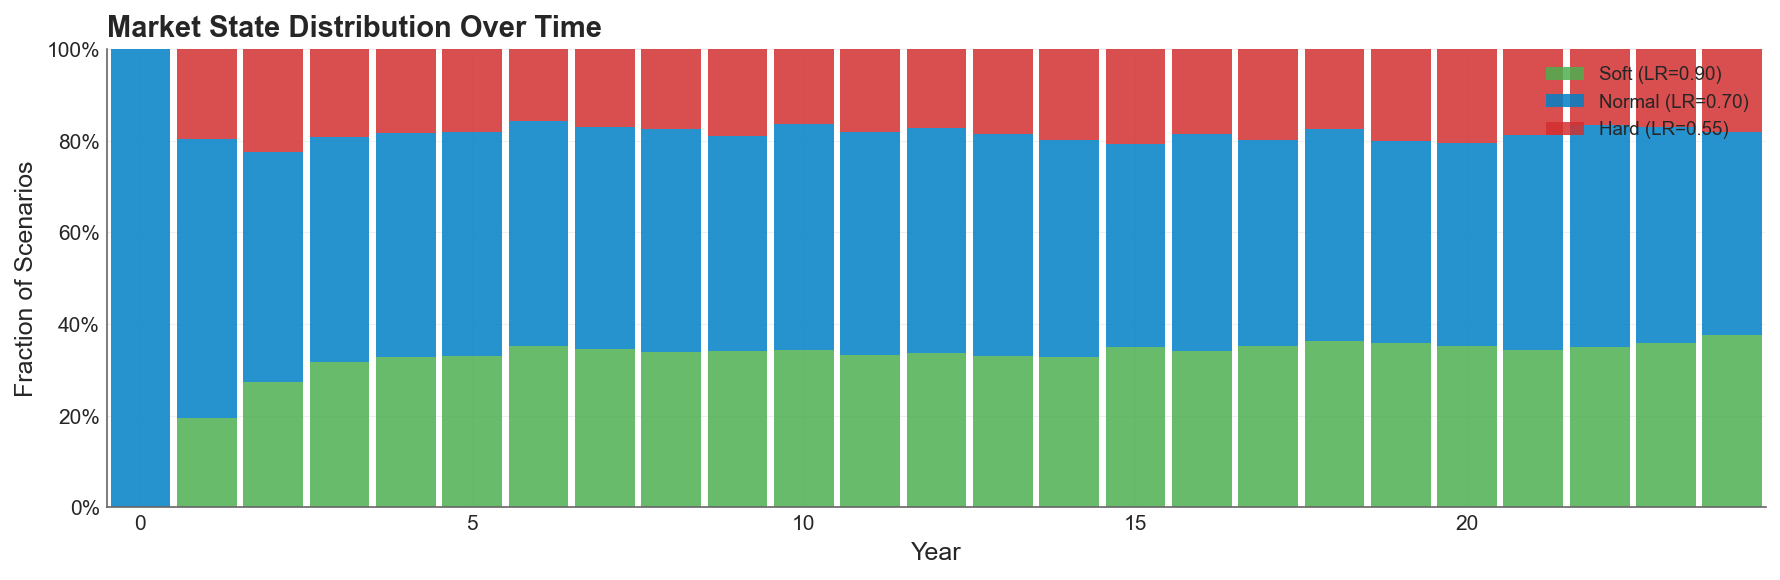

In [9]:
set_wsj_style()

# Fraction of scenarios in each state per year
state_fracs = np.zeros((3, N_YEARS))
for s in range(3):
    state_fracs[s] = (market_states == s).mean(axis=0)

MARKET_COLORS = [WSJ_COLORS.get('green', '#2ca02c'),
                 WSJ_COLORS.get('blue', '#1f77b4'),
                 WSJ_COLORS.get('red', '#d62728')]

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
years = np.arange(N_YEARS)
bottom = np.zeros(N_YEARS)
for s in range(3):
    ax.bar(years, state_fracs[s], bottom=bottom, color=MARKET_COLORS[s],
           label=f"{MARKET_NAMES[s]} (LR={MARKET_LR[s]:.2f})", width=0.9, alpha=0.85)
    bottom += state_fracs[s]
ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Scenarios")
ax.set_title("Market State Distribution Over Time", fontweight='bold', loc='left')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.5, N_YEARS - 0.5)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("plot_01_market_states.png", dpi=150, bbox_inches='tight')
plt.show()

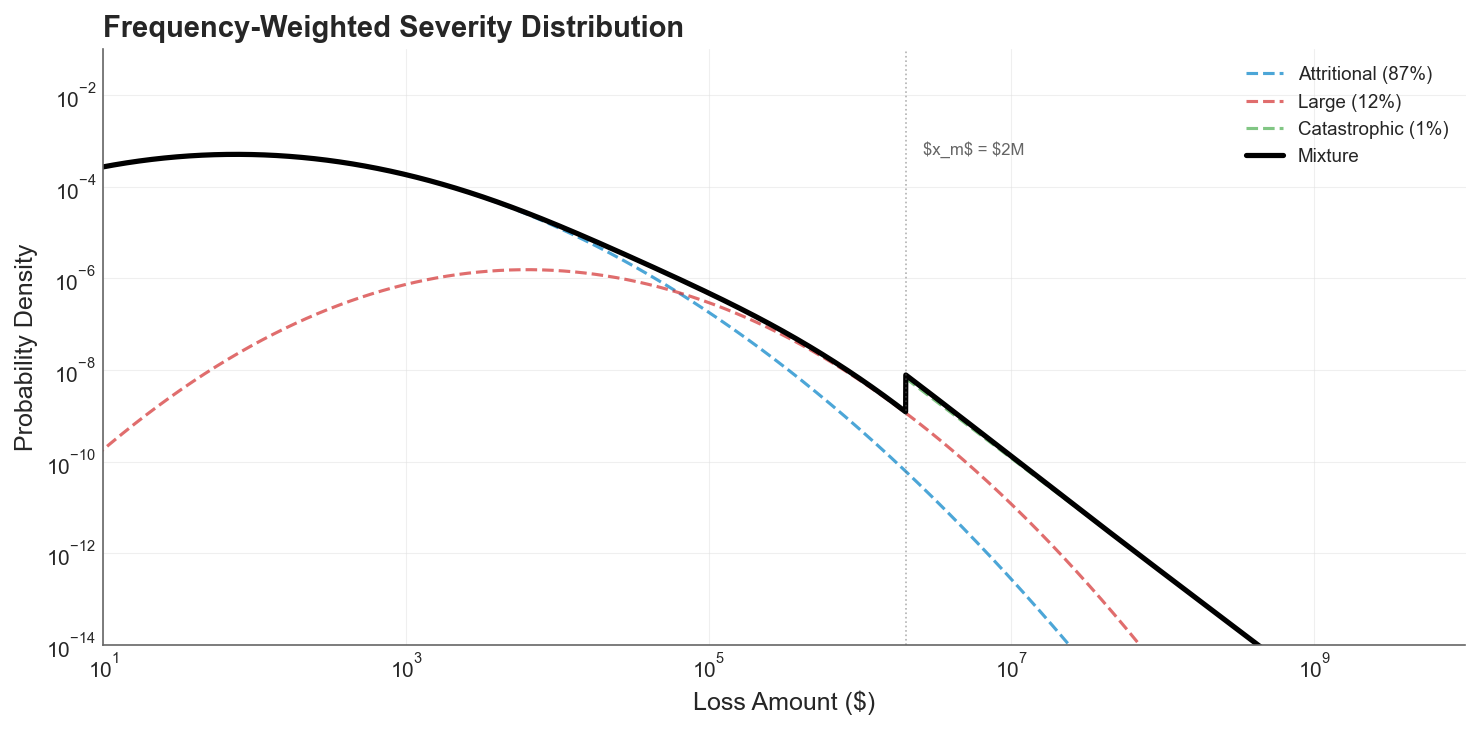

In [10]:
set_wsj_style()

xg = np.logspace(0, 10, 8000)
freq_total = ATTR_BASE_FREQ + LG_BASE_FREQ + CAT_BASE_FREQ
w_a = ATTR_BASE_FREQ / freq_total
w_l = LG_BASE_FREQ   / freq_total
w_c = CAT_BASE_FREQ  / freq_total

pdf_a = sp_lognorm.pdf(xg, s=attr_sig, scale=np.exp(attr_mu))
pdf_l = sp_lognorm.pdf(xg, s=lg_sig,   scale=np.exp(lg_mu))
cat_mask = xg >= CAT_SEV_XM
pdf_c = np.where(cat_mask,
                 CAT_SEV_ALPHA * CAT_SEV_XM**CAT_SEV_ALPHA * xg**(-CAT_SEV_ALPHA - 1), 0.0)
pdf_mix = w_a * pdf_a + w_l * pdf_l + w_c * pdf_c

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.loglog(xg, w_a * pdf_a, color=COLOR_SEQUENCE[0], lw=1.5, ls='--', alpha=0.7,
          label=f"Attritional ({w_a:.0%})")
ax.loglog(xg, w_l * pdf_l, color=COLOR_SEQUENCE[1], lw=1.5, ls='--', alpha=0.7,
          label=f"Large ({w_l:.0%})")
ax.loglog(xg[cat_mask], w_c * pdf_c[cat_mask], color=COLOR_SEQUENCE[2], lw=1.5,
          ls='--', alpha=0.7, label=f"Catastrophic ({w_c:.0%})")
ax.loglog(xg, pdf_mix, color=WSJ_COLORS.get('black', 'k'), lw=2.5, label="Mixture")
ax.axvline(CAT_SEV_XM, color=WSJ_COLORS.get('gray', 'gray'), ls=':', alpha=0.5, lw=0.8)
ax.text(CAT_SEV_XM * 1.3, 5e-4, f"$x_m$ = ${CAT_SEV_XM/1e6:.0f}M", fontsize=8,
        color=WSJ_COLORS.get('gray', 'gray'))
ax.set_xlim(10, 1e10);  ax.set_ylim(1e-14, 1e-1)
ax.set_xlabel("Loss Amount ($)")
ax.set_ylabel("Probability Density")
ax.set_title("Frequency-Weighted Severity Distribution", fontweight='bold', loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot_02_severity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

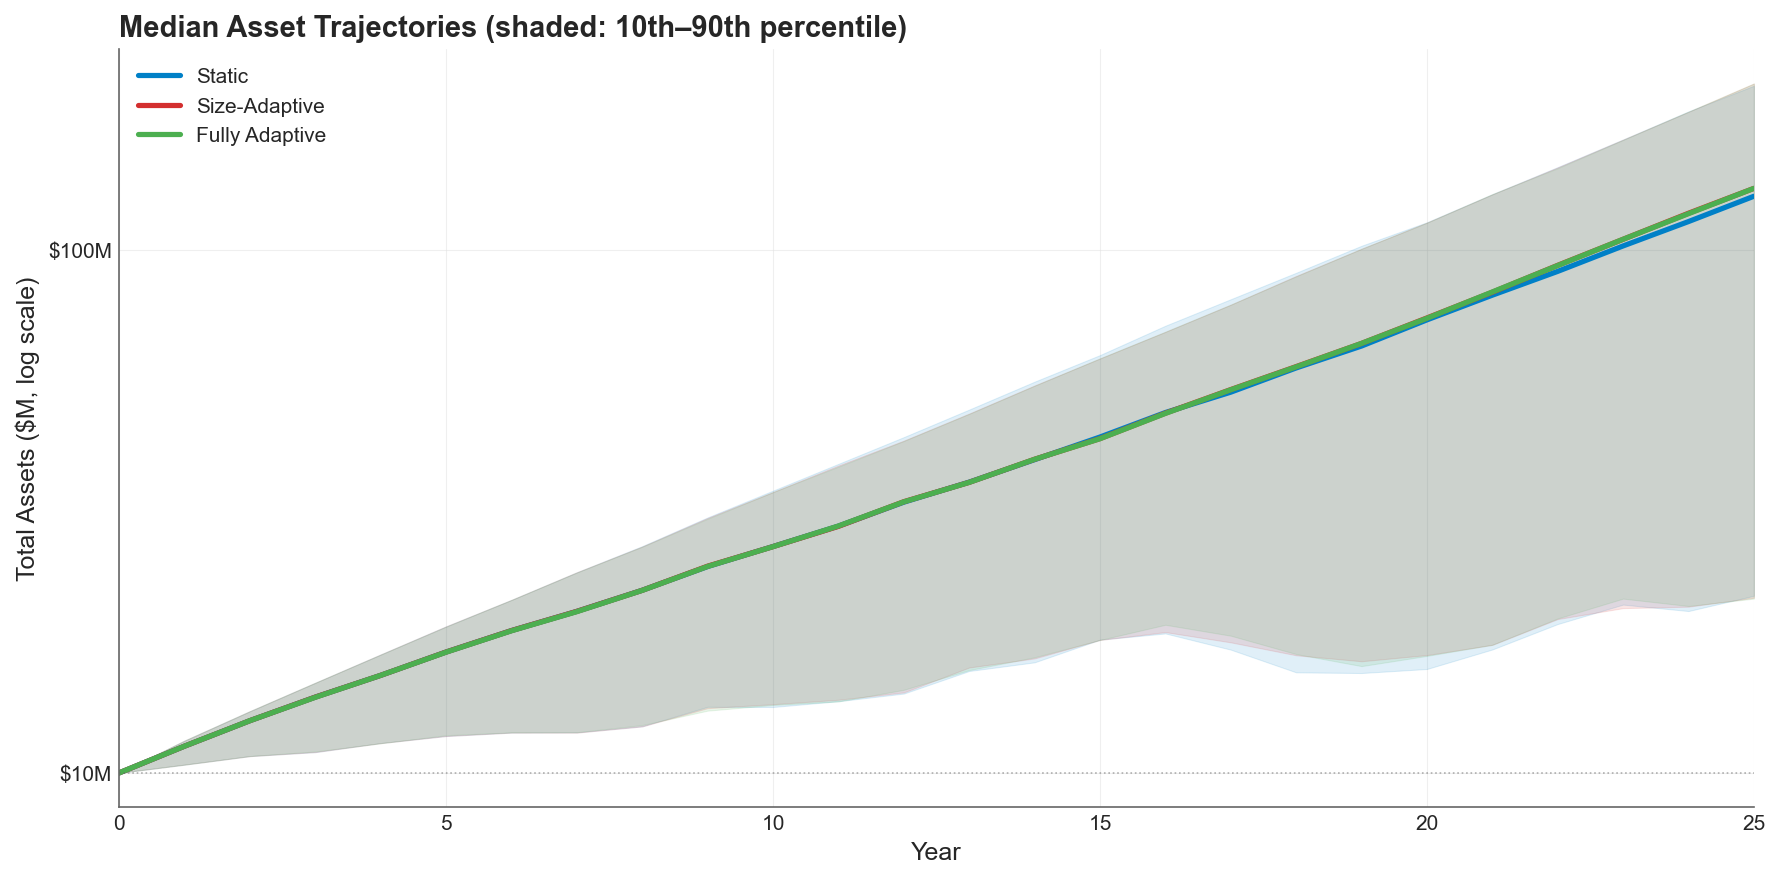

In [22]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
t_axis = np.arange(N_YEARS + 1)

for si in range(3):
    p = paths[si]
    med = np.median(p, axis=0)
    p10 = np.percentile(p, 10, axis=0)
    p90 = np.percentile(p, 90, axis=0)
    ax.semilogy(t_axis, med / 1e6, color=STRAT_COLORS[si], lw=2.5,
                label=STRAT_NAMES[si])
    ax.fill_between(t_axis, np.maximum(p10, 1) / 1e6, p90 / 1e6,
                    color=STRAT_COLORS[si], alpha=0.12)

ax.axhline(INITIAL_ASSETS / 1e6, color=WSJ_COLORS.get('gray', 'gray'),
           ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Total Assets ($M, log scale)")
ax.set_title("Median Asset Trajectories (shaded: 10th\u201390th percentile)",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1000:,.0f}K"))
ax.set_xlim(0, N_YEARS)
plt.tight_layout()
plt.savefig("plot_03_asset_paths.png", dpi=150, bbox_inches='tight')
plt.show()

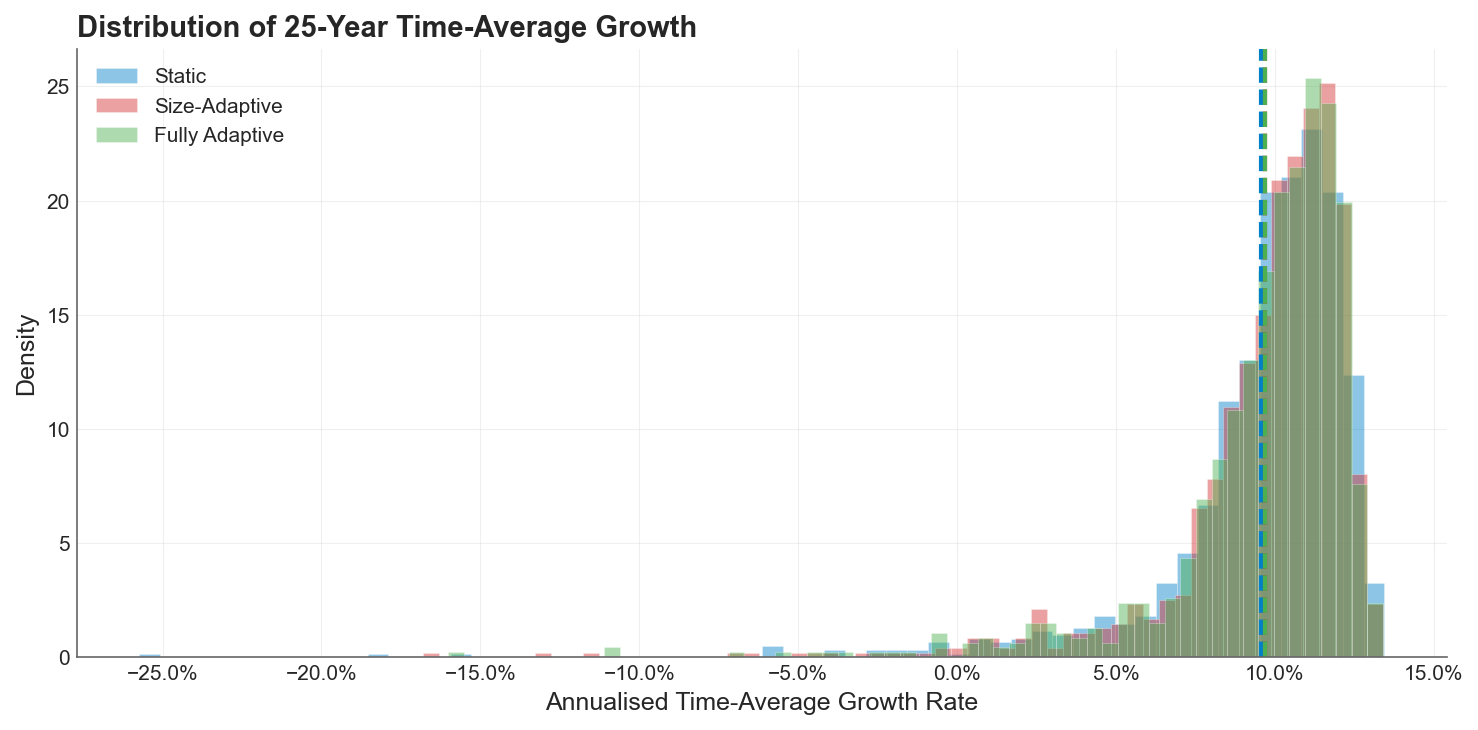

In [12]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

for si in range(3):
    fw = paths[si, :, -1]
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    alive = fw > 0
    data = lg[alive]
    ax.hist(data, bins=60, density=True, alpha=0.45,
            color=STRAT_COLORS[si], label=STRAT_NAMES[si], edgecolor='white', lw=0.3)
    ax.axvline(np.mean(data), color=STRAT_COLORS[si], ls='--', lw=2)

ax.set_xlabel("Annualised Time-Average Growth Rate")
ax.set_ylabel("Density")
ax.set_title("Distribution of 25-Year Time-Average Growth",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("plot_04_growth_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

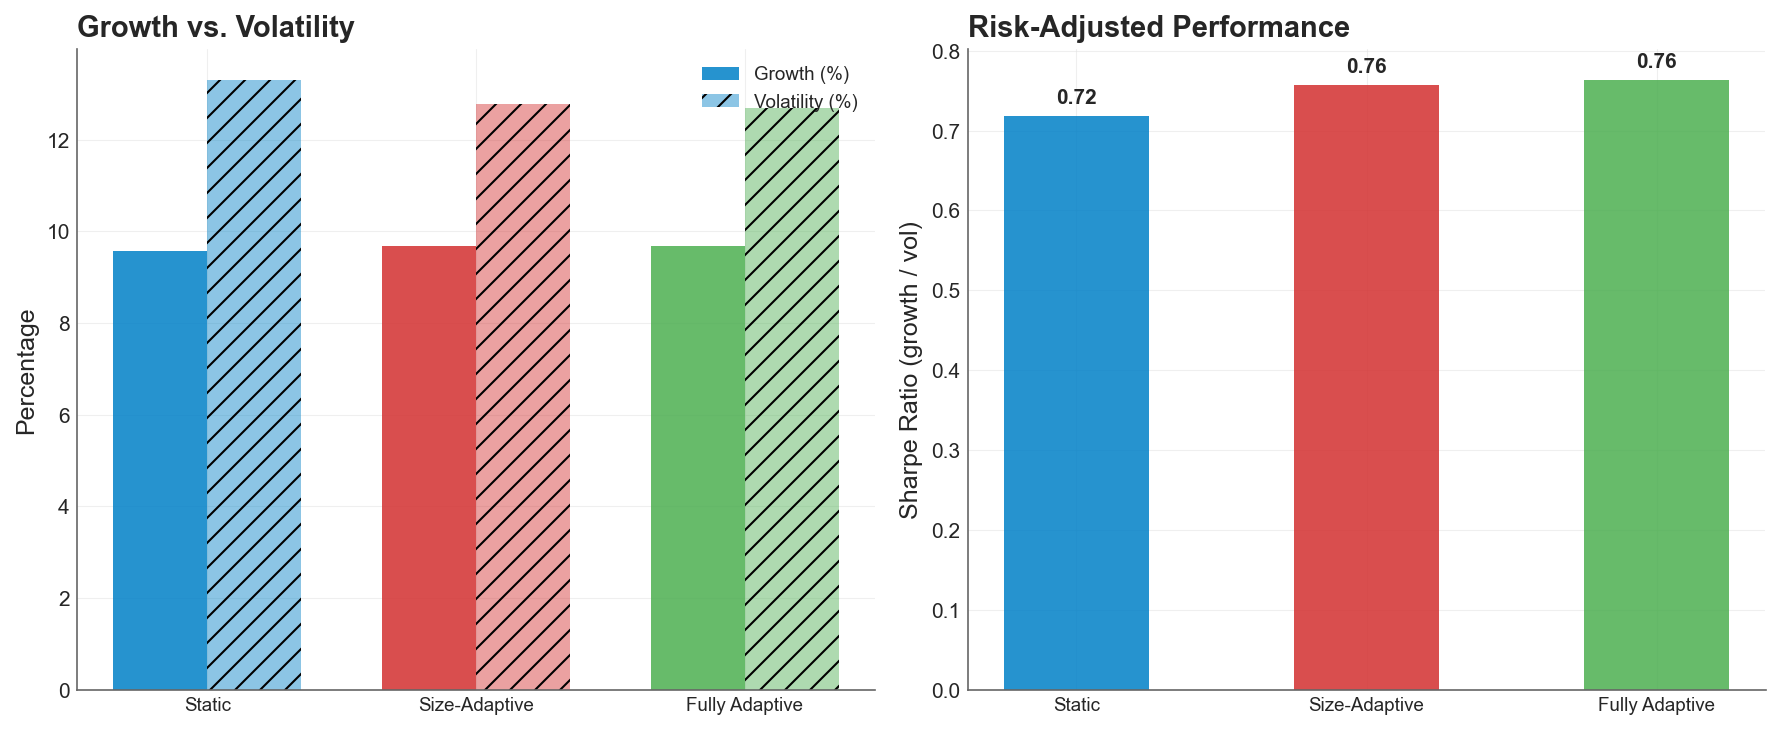

In [13]:
set_wsj_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Left: Time-average growth and volatility bars
ta_growth_vals = []
vol_vals = []
sharpe_vals = []

for si in range(3):
    fw = paths[si, :, -1]
    alive = fw > 0
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    ar = np.diff(np.log(np.maximum(paths[si], 1)), axis=1)
    ta = np.mean(lg[alive]) if alive.any() else 0
    vol = np.std(ar[alive].ravel()) if alive.any() else 0
    ta_growth_vals.append(ta)
    vol_vals.append(vol)
    sharpe_vals.append(ta / vol if vol > 0 else 0)

x = np.arange(3)
w = 0.35
bars1 = ax1.bar(x - w/2, [g * 100 for g in ta_growth_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85,
                label='Growth (%)')
bars2 = ax1.bar(x + w/2, [v * 100 for v in vol_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.45,
                label='Volatility (%)', hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(STRAT_NAMES, fontsize=9)
ax1.set_ylabel("Percentage")
ax1.set_title("Growth vs. Volatility", fontweight='bold', loc='left')
ax1.legend(fontsize=9)

# Right: Sharpe ratio
bars3 = ax2.bar(x, sharpe_vals, 0.5,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(STRAT_NAMES, fontsize=9)
ax2.set_ylabel("Sharpe Ratio (growth / vol)")
ax2.set_title("Risk-Adjusted Performance", fontweight='bold', loc='left')
for bar, val in zip(bars3, sharpe_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("plot_05_sharpe_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

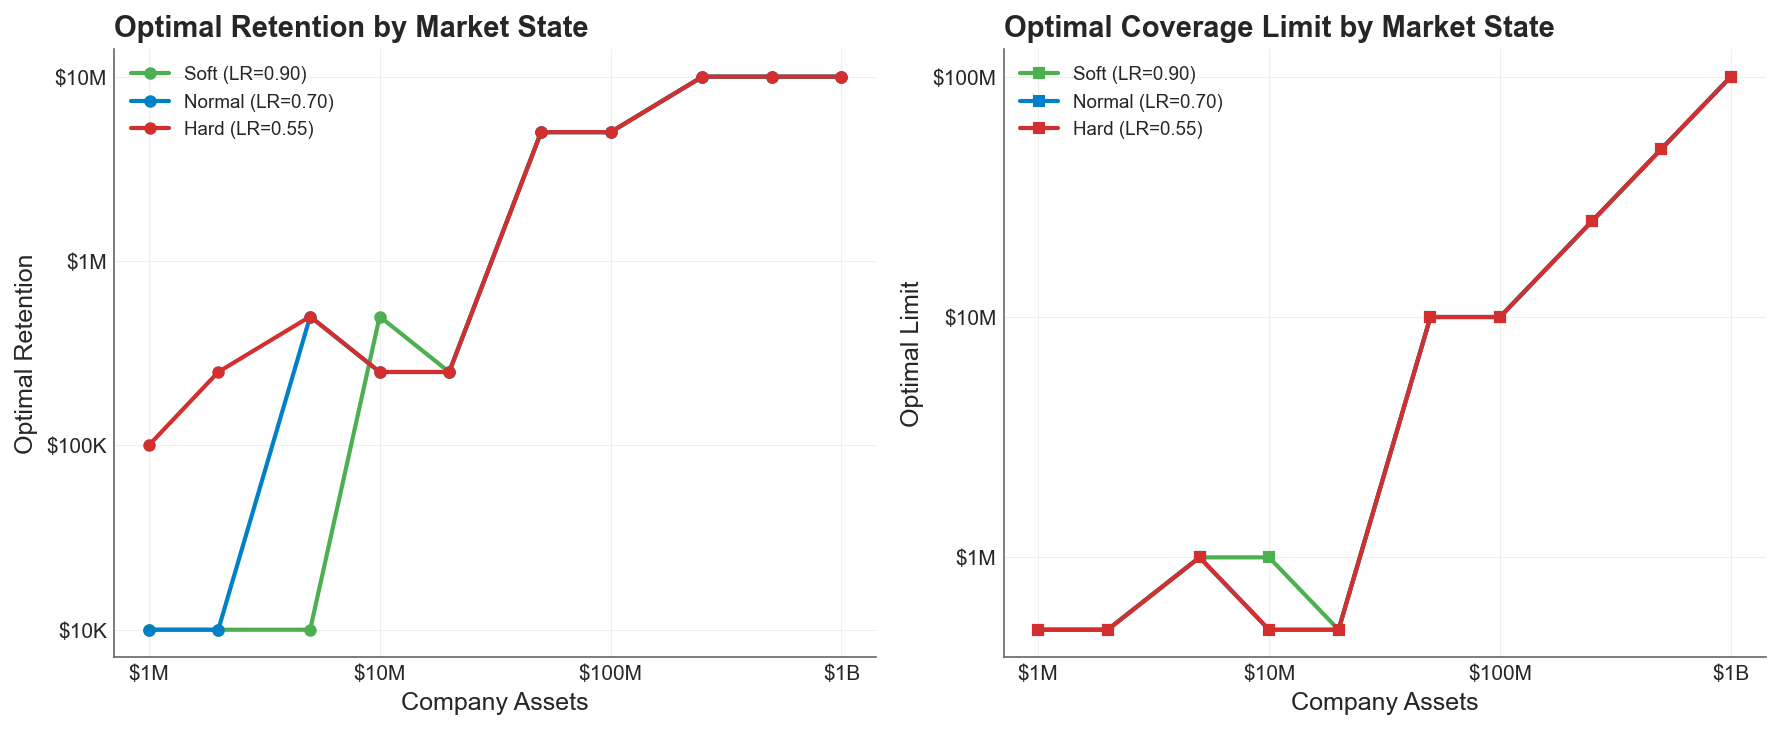

In [21]:
set_wsj_style()

def dollar_fmt(x, pos):
    if x >= 1e9:  return f'${x/1e9:.0f}B'
    elif x >= 1e6: return f'${x/1e6:.0f}M'
    elif x >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

for s_idx in range(3):
    ax1.loglog(WEALTH_GRID, optimal_ret[s_idx],
               'o-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")
    ax2.loglog(WEALTH_GRID, optimal_lim[s_idx],
               's-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")

ax1.set_xlabel("Company Assets")
ax1.set_ylabel("Optimal Retention")
ax1.set_title("Optimal Retention by Market State", fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

ax2.set_xlabel("Company Assets")
ax2.set_ylabel("Optimal Limit")
ax2.set_title("Optimal Coverage Limit by Market State", fontweight='bold', loc='left')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

plt.tight_layout()
plt.savefig("plot_06_optimal_strategy.png", dpi=150, bbox_inches='tight')
plt.show()

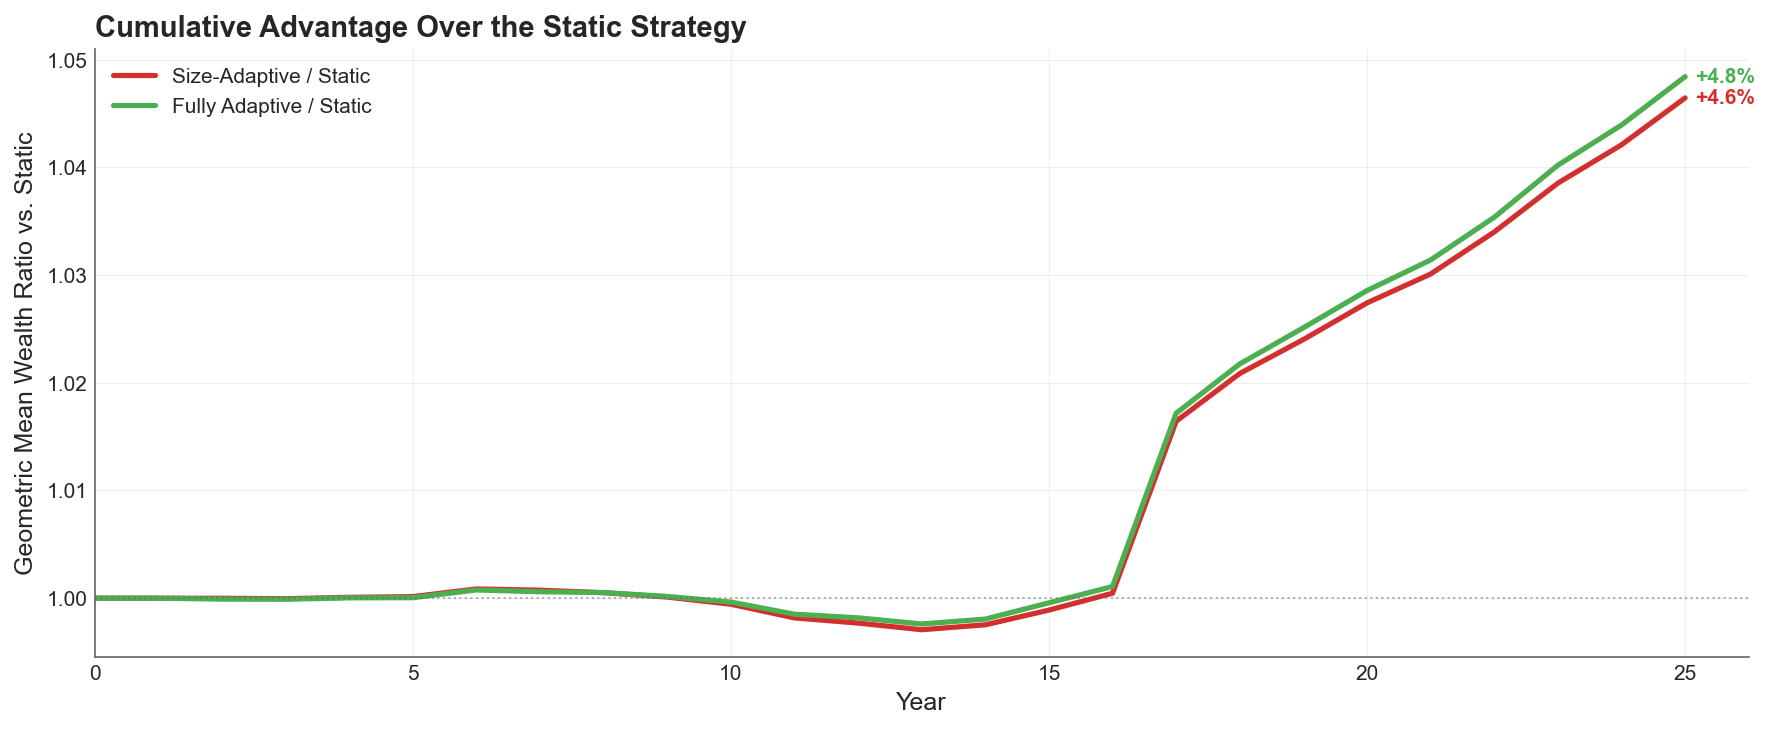

In [15]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Mean log-wealth advantage vs Static (measures time-average growth gap)
log_static = np.mean(np.log(np.maximum(paths[0], 1)), axis=0)

for si in [1, 2]:
    log_si = np.mean(np.log(np.maximum(paths[si], 1)), axis=0)
    advantage = np.exp(log_si - log_static)  # geometric mean wealth ratio
    ax.plot(t_axis, advantage, color=STRAT_COLORS[si], lw=2.5,
            label=f"{STRAT_NAMES[si]} / Static")
    # Annotate final value
    pct = (advantage[-1] - 1) * 100
    ax.annotate(f"+{pct:.1f}%", xy=(N_YEARS, advantage[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=10,
                fontweight='bold', color=STRAT_COLORS[si], va='center')

ax.axhline(1.0, color=WSJ_COLORS.get('gray', 'gray'), ls=':', lw=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Geometric Mean Wealth Ratio vs. Static")
ax.set_title("Cumulative Advantage Over the Static Strategy",
             fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, N_YEARS + 1)
plt.tight_layout()
plt.savefig("plot_07_cumulative_advantage.png", dpi=150, bbox_inches='tight')
plt.show()

## References

1. **Hamilton, J. D.** (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2),   357–384. https://doi.org/10.2307/19125592.
2. **Cummins, J. D., & Outreville, J. F.** (1987). An international analysis   of underwriting cycles in property-liability insurance. *Journal of Risk   and Insurance*, 54(2), 246–262. https://doi.org/10.2307/253226